In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
from scipy.stats import norm
import random
import math

In [2]:
import pandas as pd
data = pd.read_csv("galaxyquasar.csv")
data

,u,g,r,i,z,class,z1,zerr
0,18.97213,18.53676,18.58280,18.34936,18.29215,QSO,0.522819,0.000155
1,19.24592,17.47646,16.47817,16.04472,15.68851,GALAXY,0.122846,0.000028
2,19.43536,17.70268,16.91565,16.58327,16.39128,GALAXY,0.000000,0.000000
3,19.31626,18.18312,17.39591,16.94549,16.65395,GALAXY,0.147435,0.000009
4,19.28828,19.11188,18.88937,18.80013,18.49183,QSO,2.011455,0.000631
...,...,...,...,...,...,...,...,...
49995,19.37295,18.12382,17.39886,16.98503,16.70585,GALAXY,0.113016,0.000011
49996,18.52021,16.88262,16.03280,15.56884,15.22454,GALAXY,0.085063,0.000014
49997,18.62718,17.30876,16.87371,16.62399,16.42296,GALAXY,0.054429,0.000008
49998,19.55140,18.27711,17.62101,17.21947,17.03347,GALAXY,0.112571,0.000009


Le's look at the colors singurarly for bimodality:

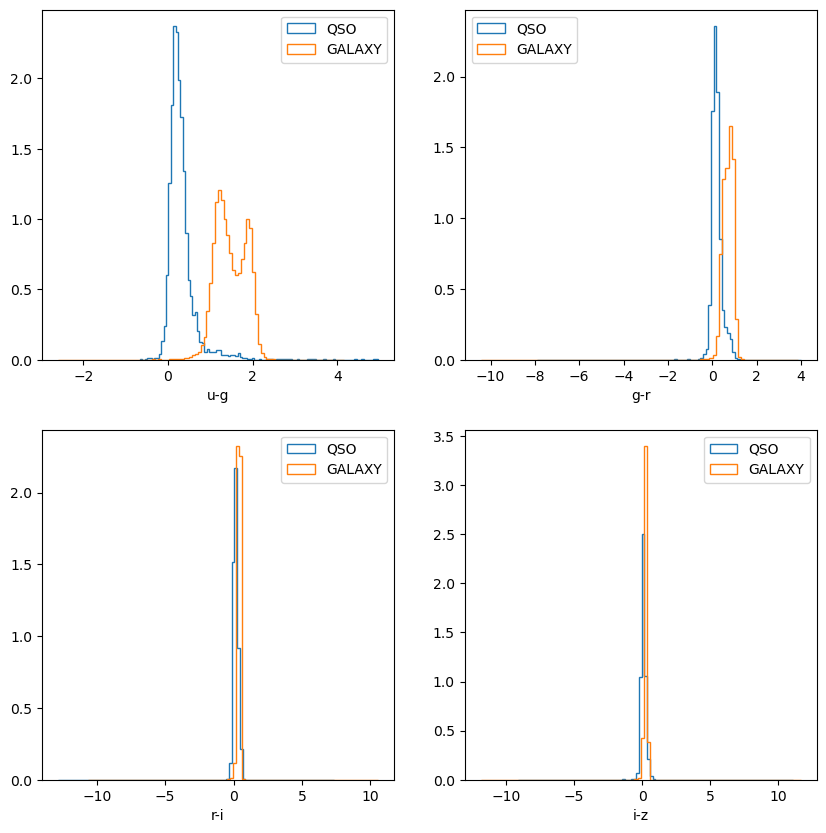

In [3]:
import seaborn as sns
fig, ax = plt.subplots(2, 2, figsize=(10,10))

qso_mask = data['class'] == 'QSO'
galaxy_mask = data['class'] == 'GALAXY'

ax[0,0].hist((data['u'][qso_mask]-data['g'][qso_mask]).to_numpy(), histtype='step', density=True, bins=100, label="QSO")
ax[0,0].hist((data['u'][galaxy_mask]-data['g'][galaxy_mask]).to_numpy(), histtype='step', density=True, bins=100, label="GALAXY")
ax[0,0].set_xlabel('u-g')
ax[0,0].legend()
ax[0,1].hist((data['g'][qso_mask]-data['r'][qso_mask]).to_numpy(), histtype='step', density=True, bins=100, label="QSO")
ax[0,1].hist((data['g'][galaxy_mask]-data['r'][galaxy_mask]).to_numpy(), histtype='step', density=True, bins=100, label="GALAXY")
ax[0,1].set_xlabel('g-r')
ax[0,1].legend()
ax[1,0].hist((data['r'][qso_mask]-data['i'][qso_mask]).to_numpy(), histtype='step', density=True, bins=100, label="QSO")
ax[1,0].hist((data['r'][galaxy_mask]-data['i'][galaxy_mask]).to_numpy(), histtype='step', density=True, bins=100, label="GALAXY")
ax[1,0].set_xlabel('r-i')
ax[1,0].legend()
ax[1,1].hist((data['i'][qso_mask]-data['z'][qso_mask]).to_numpy(), histtype='step', density=True, bins=100, label="QSO")
ax[1,1].hist((data['i'][galaxy_mask]-data['z'][galaxy_mask]).to_numpy(), histtype='step', density=True, bins=100, label="GALAXY")
ax[1,1].set_xlabel('i-z')
ax[1,1].legend()
plt.show()

u-g is where we can see better the bimodality of galaxies and quasars

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression
import matplotlib as mpl

#80% of the images as tranining dataset and leaving the other 20% as a validation set
Xtrain, Xtest = train_test_split(data,random_state=2,train_size=0.8)

In [5]:
#runna una sola volta!
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
Xtrain['class'] = le.fit_transform(Xtrain['class'])
labels_train = le.inverse_transform(Xtrain['class'])
class_names_train = le.classes_
print(class_names_train)

le = LabelEncoder()
Xtest['class'] = le.fit_transform(Xtest['class'])
labels_test = le.inverse_transform(Xtest['class'])
class_names_test = le.classes_
print(class_names_test)

['GALAXY' 'QSO']
['GALAXY' 'QSO']


In [6]:
#train
ug_train = (Xtrain['u']-Xtrain['g']).to_numpy()
gr_train = (Xtrain['g']-Xtrain['r']).to_numpy()
ri_train = (Xtrain['r']-Xtrain['i']).to_numpy()
iz_train = (Xtrain['i']-Xtrain['z']).to_numpy()
color_train = np.column_stack((ug_train,gr_train,ri_train,iz_train))
print(color_train.shape)

#test
ug_test = (Xtest['u']-Xtest['g']).to_numpy()
gr_test = (Xtest['g']-Xtest['r']).to_numpy()
ri_test = (Xtest['r']-Xtest['i']).to_numpy()
iz_test = (Xtest['i']-Xtest['z']).to_numpy()
color_test = np.column_stack((ug_test,gr_test,ri_test,iz_test))
print(color_test.shape)

(40000, 4)
(10000, 4)


## Gaussian Naive Bayes

In [7]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()
gnb.fit(color_train,Xtrain['class'].to_numpy())

y_pred = gnb.predict(color_test)

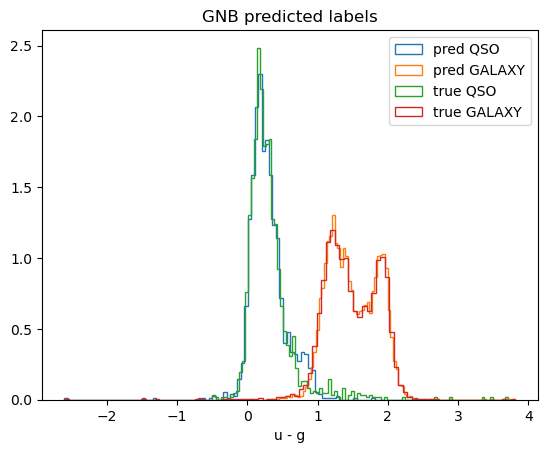

score:  0.9696


In [8]:
plt.hist(x=color_test[:,0][y_pred==1], histtype='step', density=True, bins=100, label='pred QSO')
plt.hist(x=color_test[:,0][y_pred==0], histtype='step', density=True, bins=100, label='pred GALAXY')
plt.xlabel('u - g')
plt.title('GNB predicted labels')

plt.hist(x=color_test[:,0][Xtest['class']==1], histtype='step', density=True, bins=100, label='true QSO')
plt.hist(x=color_test[:,0][Xtest['class']==0], histtype='step', density=True, bins=100, label='true GALAXY')
plt.xlabel('u - g')
plt.legend()
plt.show()

print('score: ', gnb.score(color_test,Xtest['class']))

## GMM Bayes

In [9]:
from astroML.classification import GMMBayes
from sklearn.model_selection import GridSearchCV

K = 5 # Do 5-fold cross validation
n = np.arange(1,11)

GMM_Bayes = GMMBayes(3)
grid = GridSearchCV(GMM_Bayes, {'n_components': n}, cv = K, scoring='neg_mean_squared_error') # Try each degree with K-folds
grid.fit(color_train,Xtrain['class'].to_numpy())
opt_n = grid.best_params_['n_components']
print('Optimal n_components through cross validation: %i' % opt_n)

Optimal n_components through cross validation: 10


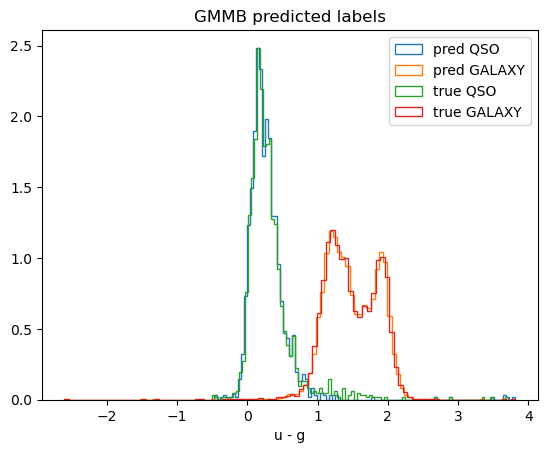

score:  0.9847


In [10]:
gmmb = GMMBayes(opt_n)
gmmb.fit(color_train,Xtrain['class'].to_numpy())

y_GMMB = gmmb.predict(color_test)

plt.hist(x=color_test[:,0][y_GMMB==1], histtype='step', density=True, bins=100, label='pred QSO')
plt.hist(x=color_test[:,0][y_GMMB==0], histtype='step', density=True, bins=100, label='pred GALAXY')
plt.xlabel('u - g')
plt.title('GMMB predicted labels')
plt.hist(x=color_test[:,0][Xtest['class']==1], histtype='step', density=True, bins=100, label='true QSO')
plt.hist(x=color_test[:,0][Xtest['class']==0], histtype='step', density=True, bins=100, label='true GALAXY')
plt.xlabel('u - g')
plt.legend()
plt.show()

print('score: ', gmmb.score(color_test,Xtest['class']))

## K-Neares Neighor

In [11]:
from sklearn.neighbors import KNeighborsClassifier

knc = KNeighborsClassifier(5) # use 5 nearest neighbors
k = np.arange(5,51,5)

grid = GridSearchCV(knc, {'n_neighbors': k}, cv = K, scoring='neg_mean_squared_error') # Try each degree with K-folds
grid.fit(color_train,Xtrain['class'].to_numpy())
opt_k = grid.best_params_['n_neighbors']
print('Optimal n_neighbors through cross validation: %i' % opt_k)

Optimal n_neighbors through cross validation: 15


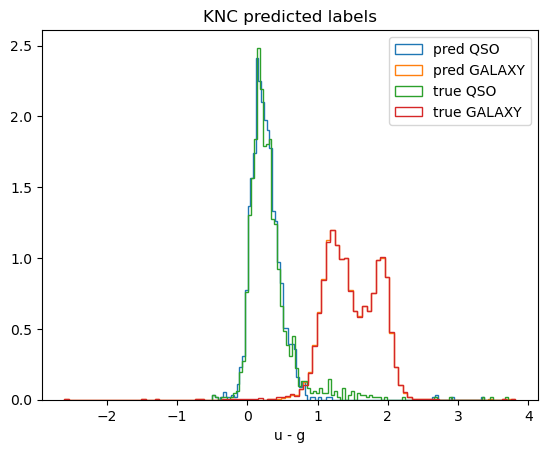

score:  0.9847


In [12]:
knc = KNeighborsClassifier(opt_k)
knc.fit(color_train,Xtrain['class'].to_numpy())

y_knc = knc.predict(color_test)

plt.hist(x=color_test[:,0][y_knc==1], histtype='step', density=True, bins=100, label='pred QSO')
plt.hist(x=color_test[:,0][y_knc==0], histtype='step', density=True, bins=100, label='pred GALAXY')
plt.xlabel('u - g')
plt.title('KNC predicted labels')
plt.hist(x=color_test[:,0][Xtest['class']==1], histtype='step', density=True, bins=100, label='true QSO')
plt.hist(x=color_test[:,0][Xtest['class']==0], histtype='step', density=True, bins=100, label='true GALAXY')
plt.xlabel('u - g')
plt.legend()
plt.show()

print('score: ', gmmb.score(color_test,Xtest['class']))

# ROC curves

In [13]:
from sklearn.discriminant_analysis import (LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis)

from sklearn.metrics import roc_curve
from sklearn.metrics import precision_recall_curve

from astroML.utils import split_samples, completeness_contamination
from astroML.datasets import fetch_rrlyrae_combined

GaussianNB
LinearDiscriminantAnalysis
QuadraticDiscriminantAnalysis
KNeighborsClassifier
GMMBayes


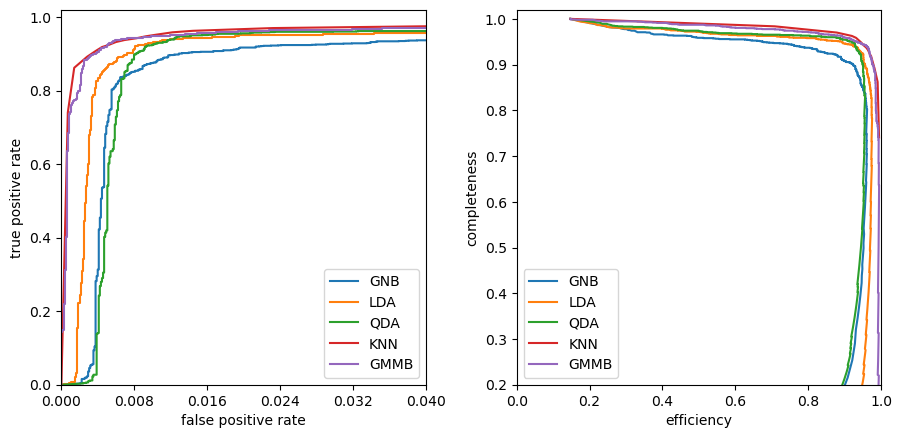

In [14]:
# Fit all the models to the training data
def compute_models(*args):
    names = []
    probs = []
    for classifier, kwargs in args:
        print(classifier.__name__)
        clf = classifier(**kwargs)
        clf.fit(color_train, Xtrain['class'].to_numpy())
        
        #Note that we are outputing the probabilities [of class 1], not the classes
        y_probs = clf.predict_proba(color_test)[:, 1]

        names.append(classifier.__name__)
        probs.append(y_probs)

    return names, probs

names, probs = compute_models((GaussianNB, {}),
                              (LinearDiscriminantAnalysis, {}),
                              (QuadraticDiscriminantAnalysis, {}),
                              (KNeighborsClassifier,
                               dict(n_neighbors=opt_k)),
                              (GMMBayes, dict(n_components=opt_n)))

# Plot ROC curves and completeness/efficiency
fig = plt.figure(figsize=(15, 5))
fig.subplots_adjust(left=0.1, right=0.95, bottom=0.15, top=0.9, wspace=0.25)

# ax1 will show roc curves
ax1 = plt.subplot(131)

# ax2 will show completeness/efficiency
ax2 = plt.subplot(132)

# ax3 will show precision/recall
# ax3 = plt.subplot(133)

labels = dict(GaussianNB='GNB',
              LinearDiscriminantAnalysis='LDA',
              QuadraticDiscriminantAnalysis='QDA',
              KNeighborsClassifier='KNN',
              GMMBayes='GMMB')

thresholds = np.linspace(0, 1, 50001)[:-1]

# iterate through and show results
for name, y_prob in zip(names, probs):
    fpr, tpr, thresh = roc_curve(Xtest['class'].to_numpy(), y_prob)
    precision, recall, thresh2 = precision_recall_curve(Xtest['class'].to_numpy(), y_prob)

    # add (0, 0) as first point
    fpr = np.concatenate([[0], fpr])
    tpr = np.concatenate([[0], tpr])
    # Here we add (1,0) 
    precision = np.concatenate([[0], precision])
    recall = np.concatenate([[1], recall])
    thresh2 = np.concatenate([[0], thresh2])

    ax1.plot(fpr, tpr, label=labels[name])

    #See note above about astroML vs. sklearn
    #Note that the range of threshhold values here is 0% to 100% (0.0 to 1.0)
    comp = np.zeros_like(thresholds)
    cont = np.zeros_like(thresholds)
    for i, t in enumerate(thresholds):
        y_pred = (y_prob >= t)
        comp[i], cont[i] = completeness_contamination(y_pred, Xtest['class'].to_numpy())
    ax2.plot(1 - cont, comp, label=labels[name])
    
    #ax3.plot(precision, recall, label=labels[name])

ax1.set_xlim(0, 0.04)
ax1.set_ylim(0, 1.02)
ax1.xaxis.set_major_locator(plt.MaxNLocator(5))
ax1.set_xlabel('false positive rate')
ax1.set_ylabel('true positive rate')
ax1.legend(loc=4)

ax2.set_xlabel('efficiency')
ax2.set_ylabel('completeness')
ax2.set_xlim(0, 1.0)
ax2.set_ylim(0.2, 1.02)
ax2.legend()

#ax3.set_xlabel('precision')
#ax3.set_ylabel('recall')
#ax3.set_xlim(0, 1.0)
#ax3.set_ylim(0.2, 1.02)

plt.show()

Pretty good results!

The best classificators in the ones considered are KNN and GMMB: high true positive with small false positive rates and high completeness with high efficiency.